# Task 2: Hypertension Prediction and ROC-AUC Curve Evaluation



In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score, confusion_matrix, 
    classification_report, accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/Users/ahad.anwer/Workspace/Assignments/pamlp_setexercise_g1_rules/Dataset/Task2_hypertension_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Features: {df.shape[1] - 1}")
print(f"Samples: {df.shape[0]}")

print("\nFirsts Few Rows ===")
display(df.head())

print("\n Dataset Info ===")
print(df.info())

print("\nData description numeric:")
print(df.describe())

print("\nData description categorical:")
print(df.describe(include=['object']))

Dataset shape: (1985, 11)
Features: 10
Samples: 1985

Firsts Few Rows ===


,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No



 Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 170.7+ KB
None

Data description numeric:
               Age  Salt_Intake  Stress_Score  Sleep_Duration          BMI
count  1985.000000  1985.000000   1985.000000     1985.000000  1985.000000
mean     50.34105

In [2]:
# Encode categorical variables
cat_cols = ['BP_History', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status']
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode target variable
df['Has_Hypertension'] = df['Has_Hypertension'].map({'Yes': 1, 'No': 0})

# Features and target
X = df.drop('Has_Hypertension', axis=1)
y = df['Has_Hypertension']



In [3]:

# Check and handle missing values in the dataset
print("\nMissing values per column:\n", df.isnull().sum())
df['Medication'] = df['Medication'].fillna('NA')

print("\nAfter handling missing values:")
print(df.isnull().sum())


Missing values per column:
 Age                 0
Salt_Intake         0
Stress_Score        0
BP_History          0
Sleep_Duration      0
BMI                 0
Medication          0
Family_History      0
Exercise_Level      0
Smoking_Status      0
Has_Hypertension    0
dtype: int64

After handling missing values:
Age                 0
Salt_Intake         0
Stress_Score        0
BP_History          0
Sleep_Duration      0
BMI                 0
Medication          0
Family_History      0
Exercise_Level      0
Smoking_Status      0
Has_Hypertension    0
dtype: int64


In [4]:
# Standardize numeric features
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict probabilities and classes
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)



In [6]:
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
auc_value = auc(fpr, tpr)

# Calculate additional metrics for report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print all necessary metrics for the report
print("\n=== Model Performance Metrics ===")
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"AUC (from roc_curve): {auc_value:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Classification report
# Generate and print a detailed classification report in a clean, readable format
report = classification_report(
    y_test, 
    y_pred, 
    target_names=['No Hypertension', 'Has Hypertension']
)
print(report)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (actual vs predicted):")
print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}, False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")

print("\nFeature Importance (Random Forest)")
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importance)


=== Model Performance Metrics ===
ROC AUC Score: 0.9949
AUC (from roc_curve): 0.9949
Accuracy: 0.9647
Precision: 0.9704
Recall: 0.9610
F1 Score: 0.9657
                  precision    recall  f1-score   support

 No Hypertension       0.96      0.97      0.96       192
Has Hypertension       0.97      0.96      0.97       205

        accuracy                           0.96       397
       macro avg       0.96      0.96      0.96       397
    weighted avg       0.96      0.96      0.96       397


Confusion Matrix (actual vs predicted):
True Negatives: 186, False Positives: 6, False Negatives: 8, True Positives: 197

Feature Importance (Random Forest)
BP_History        0.286027
Age               0.128717
Stress_Score      0.098539
BMI               0.096404
Salt_Intake       0.095402
Sleep_Duration    0.094526
Family_History    0.091427
Smoking_Status    0.078545
Medication        0.018513
Exercise_Level    0.011900
dtype: float64


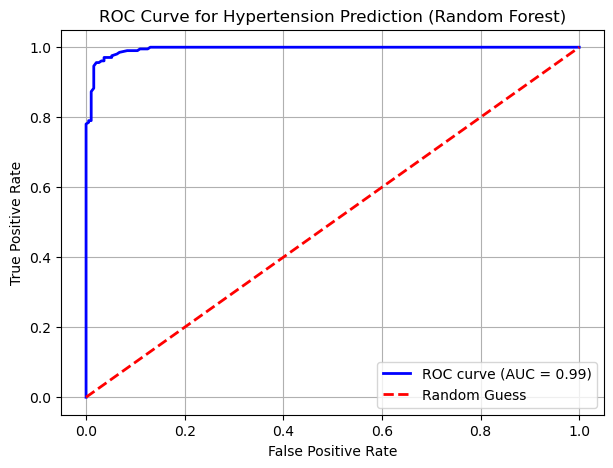

In [7]:


# ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Hypertension Prediction (Random Forest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
plt.show()


/var/folders/dy/s9b72v051rqdt2m2dhjrcn1h0000gn/T/ipykernel_50817/2706790477.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')


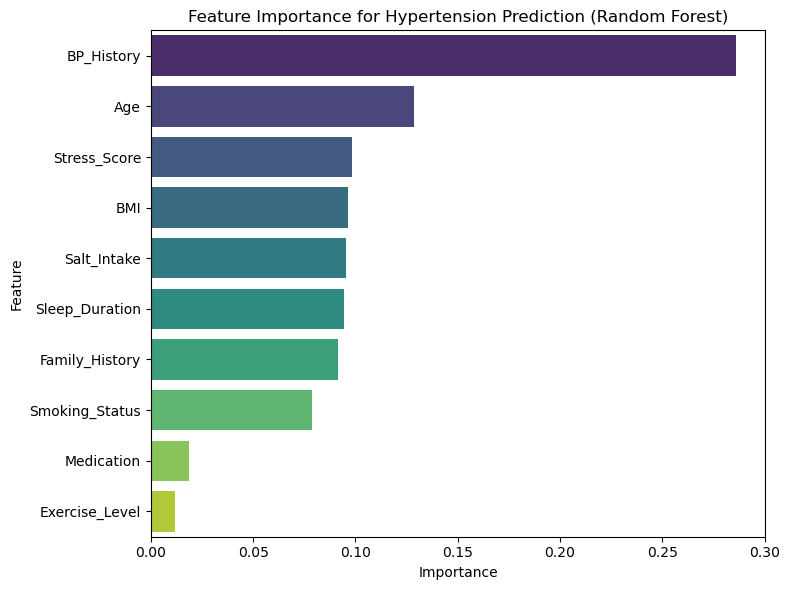

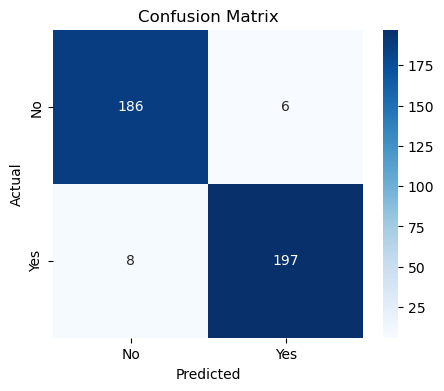

In [8]:





# Feature Importance Barplot
plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')
plt.title('Feature Importance for Hypertension Prediction (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

